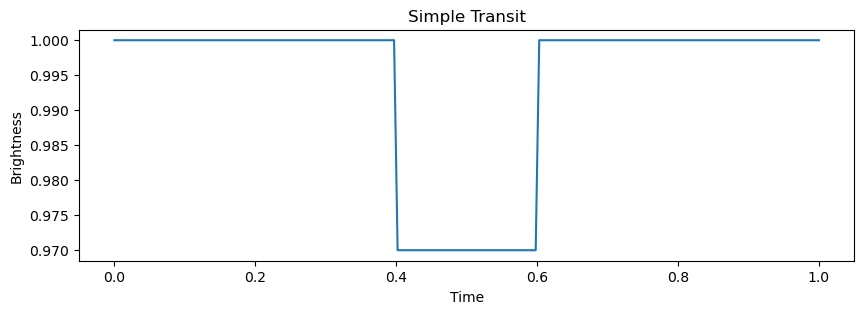

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 200 time points
x = np.linspace(0, 1, 200)

# constant brightness
y = np.ones_like(x)

# Add a transit
y[80:120] = 0.97

plt.figure(figsize=(10,3))
plt.plot(x, y)
plt.xlabel("Time")
plt.ylabel("Brightness")
plt.title("Simple Transit")
plt.show()

In [2]:
import torch

lightcurve = torch.tensor(y, dtype=torch.float32)

print(lightcurve.shape)

torch.Size([200])


In [3]:
lightcurve = lightcurve.unsqueeze(0)
lightcurve = lightcurve.unsqueeze(0)

print(lightcurve.shape)

torch.Size([1, 1, 200])


In [4]:
import torch.nn as nn
#Conv1d layer stores its filters in the weight tensor.
conv = nn.Conv1d(
    in_channels=1,
    out_channels=4,
    kernel_size=5
)
output = conv(lightcurve)

print(output.shape) #Lout=Lin−kernel_size+1

torch.Size([1, 4, 196])


In [5]:
print(conv.weight.shape)
# 4 filters (out_channels), 1 input channel (in_channels), 5 weights per filter (kernel_size)
print(conv.weight)

torch.Size([4, 1, 5])
Parameter containing:
tensor([[[ 0.3021,  0.0557, -0.2389, -0.1255,  0.0088]],

        [[ 0.3239,  0.3528,  0.0955,  0.3051,  0.4452]],

        [[-0.1666,  0.1911, -0.1725,  0.0709, -0.4024]],

        [[-0.0682, -0.2621,  0.1608, -0.1962,  0.1866]]], requires_grad=True)


In [7]:
print(output) #4arrays=>Each feature map is the response of one learned filter at every position in the light curve.
#4 features, edge, flat, noise detector, another useful pattern

tensor([[[-0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2999,
          -0.2962, -0.2890, -0.2907, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997, -0.2997,
          -0.2997, -0.2997, -0.2997, -0.2997, -0.29

Implementing Conv1D from scratch

In [8]:
signal = [1.0, 1.0, 1.0, 0.9, 0.8, 0.9, 1.0, 1.0]
kernel = [-1, 0, 1]

output = []

for i in range(len(signal) - len(kernel) + 1):
    window = signal[i:i + len(kernel)]

    value = 0

    for j in range(len(kernel)):
        value += window[j] * kernel[j]

    output.append(value)

print(output)

[0.0, -0.09999999999999998, -0.19999999999999996, 0.0, 0.19999999999999996, 0.09999999999999998]


In [ ]:
#conv = nn.Conv1d(1, 64, kernel_size=5)
# for each filter:
#     for each position:
#         output = dot(window, filter)


Activation Functions - Relu, Prelu

In [ ]:
#Relu-> +ve Ive found this pattern, -ve -> definitely not. Relu ignores negative responses; Everything below zero if flatenned
#leaky Relu-> instead of completing ignoring negative value which makes it dead neuron forever, just have a small negative value so gradients could still flow
#Parametric Relu(PReLu)->Instead of having fixed value of negative neuron, it learns and adapts value for it itself
#Relu->0, Leaky Relu-> x, Prelu-> alpha * x. Alpha is learned during training

In [9]:
import torch
import torch.nn as nn

relu = nn.ReLU()

x = torch.tensor([-2., -1., 0., 1., 2.])

print(relu(x))

tensor([0., 0., 0., 1., 2.])


In [10]:
#Prelu

prelu = nn.PReLU()
print(prelu.weight) # requires_grad=True-> backprop updates alpha just like another weight

Parameter containing:
tensor([0.2500], requires_grad=True)


In [11]:
pool = nn.MaxPool1d(kernel_size=2)
x = torch.tensor([
    [[1.,2.,5.,4.,3.,7.,1.,0.]]
                 ])
print(pool(x))

tensor([[[2., 5., 7., 1.]]])


In [18]:
class ConvBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size = 5,
            padding=2
        ),
        nn.PReLU(),
        nn.Conv1d(
                out_channels,
                out_channels,
                kernel_size=5,
                padding=2
            ),
        nn.PReLU(),
        nn.MaxPool1d(kernel_size=2)
        )
    def forward(self,x):
        return self.block(x)

Test

In [19]:
x = torch.randn(1,1,200)
block = ConvBlock(
    in_channels =1, # brightness
    out_channels = 16 #learn 16 different filters, deep layers need more feature detectors
)
y = block(x)
print(y.shape)
# (1,1,200) => (1,16,200) 16 different interpretation of same brightness signal

torch.Size([1, 16, 100])
